# Lekcja 18: Wprowadzenie do ML

Pełne treści zadań z podręcznika


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
np.random.seed(42)
sns.set_theme(style='whitegrid')

from sklearn.datasets import (
    load_iris, load_wine, load_breast_cancer, load_digits,
    make_blobs, make_classification, make_multilabel_classification
)
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, OneClassSVM
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    VotingClassifier, IsolationForest, GradientBoostingClassifier
)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_squared_error, r2_score, silhouette_score, hamming_loss
)

print('Importy OK!')

Importy OK!


---
## ✏️ Zadania podstawowe (1–8)

### ✏️ Zadanie 1 – Pierwszy model klasyfikacji

Wytrenuj model LogisticRegression na datasecie Iris i oceń jego accuracy.

**Wymagania:**
- Podziel dane 80/20 (train/test)
- Zastosuj standaryzację
- Wydrukuj accuracy na zbiorze testowym

*(proste)*

In [4]:
iris_data = load_iris()

x_train, x_test, y_train, y_test = train_test_split(
    iris_data.data, iris_data.target, test_size=0.2, random_state=42
)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

log_reg = LogisticRegression()

log_reg.fit(x_train, y_train)

y_pred = log_reg.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


### ✏️ Zadanie 2 – Porównanie trzech algorytmów

Porównaj accuracy trzech algorytmów na datasecie Wine: LogisticRegression, DecisionTree, KNN.

**Wymagania:**
- Ten sam podział train/test dla wszystkich
- Wydrukuj wyniki w formie tabeli

*(proste)*

In [7]:
wine_data = load_wine()

x_train, x_test, y_train, y_test = train_test_split(
    wine_data.data, wine_data.target, test_size=0.2, random_state=42
    )

log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)
y_pred_log = log_reg.predict(x_test)

dtree = DecisionTreeClassifier()
dtree.fit(x_train, y_train)
y_pred_dtree = dtree.predict(x_test)

knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dtree))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

Logistic Regression Accuracy: 0.9722222222222222
Decision Tree Accuracy: 0.9444444444444444
KNN Accuracy: 0.7222222222222222


### ✏️ Zadanie 3 – Confusion Matrix

Dla klasyfikacji binarnej na Breast Cancer dataset, stwórz i zwizualizuj confusion matrix.

**Wymagania:**
- Użyj Random Forest
- Heatmap confusion matrix z annotacjami
- Oblicz precision, recall, F1

*(proste)*

Precision: 0.96
Recall: 0.97
F1 Score: 0.97


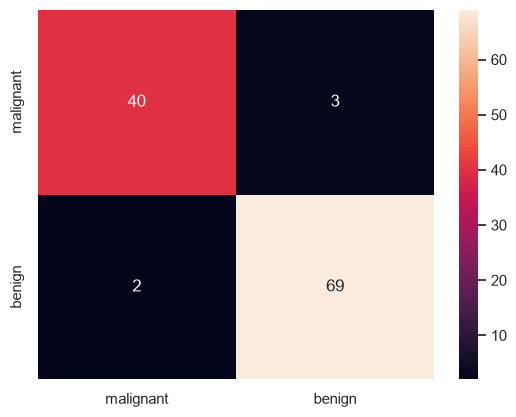

In [95]:
breast_cancer_data = load_breast_cancer()

x_train, x_test, y_train, y_test = train_test_split(
    breast_cancer_data.data, breast_cancer_data.target, test_size=0.2, random_state=42
)

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

heatmap = sns.heatmap(cm, annot=True, xticklabels=breast_cancer_data.target_names, yticklabels=breast_cancer_data.target_names)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

### ✏️ Zadanie 4 – Regresja liniowa

Przeprowadź regresję liniową na California Housing i oceń R².

**Wymagania:**
- Standaryzacja cech
- Oblicz RMSE i R²
- Scatter plot: predicted vs actual

*(proste)*

> *Uwaga: `fetch_california_housing()` wymaga pobrania z internetu, które bywa zablokowane —
> używamy syntetycznych danych o identycznej strukturze (te same nazwy cech, podobne rozkłady).*

### ✏️ Zadanie 5 – K-Means clustering

Przeprowadź klasteryzację K-Means na syntetycznych danych.

**Wymagania:**
- Użyj metody łokcia do wyboru k
- Zwizualizuj klastry z centroidami

*(proste)*

### ✏️ Zadanie 6 – PCA na Digits

Przeprowadź PCA na datasecie Digits i zwizualizuj w 2D.

**Wymagania:**
- Redukcja do 2 komponentów
- Scatter plot z kolorowaniem według cyfry
- Ile % wariancji wyjaśnia 2 komponenty?

*(proste)*

### ✏️ Zadanie 7 – Cross-Validation

Przeprowadź 5-fold cross-validation dla Random Forest na Iris.

**Wymagania:**
- Użyj StratifiedKFold
- Wydrukuj mean i std accuracy
- Boxplot scores per fold

*(proste)*

In [ ]:
iris_data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    iris_data.data,
    iris_data.target,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy')

print(f"Cross-validation scores: {scores}")



Cross-validation scores: [0.95833333 0.95833333 0.875      0.95833333 0.91666667]


### ✏️ Zadanie 8 – Feature Importance

Dla Random Forest na Wine dataset, zwizualizuj feature importance.

**Wymagania:**
- Horizontal bar plot
- Sortowanie od najważniejszej
- Dodaj wartości na słupkach

*(proste)*

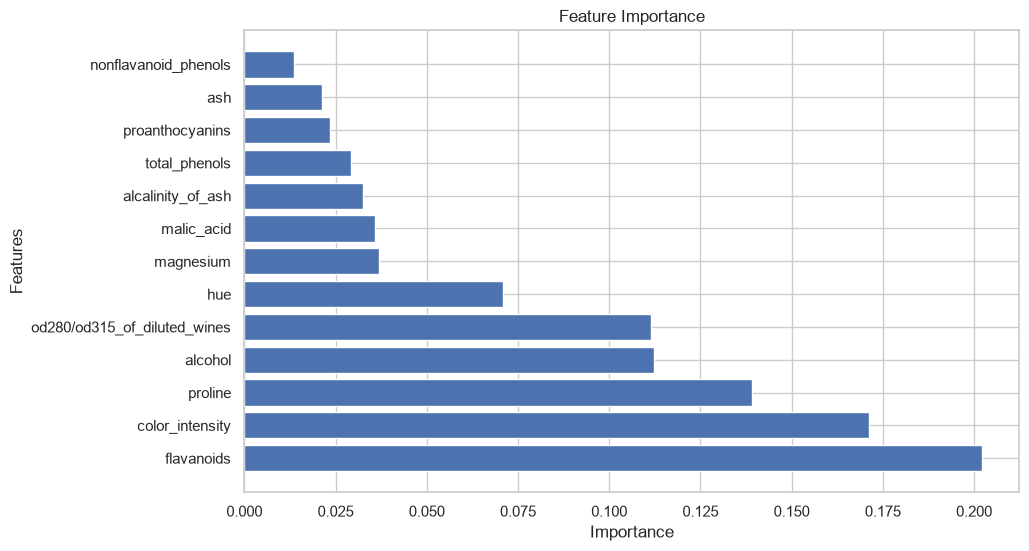

In [18]:
wine_data = load_wine()

x_train, x_test, y_train, y_test = train_test_split(
    wine_data.data, wine_data.target, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(
    range(len(indices)),
    importances[indices],
    color='b'
)
plt.yticks(
    range(len(indices)),
    [wine_data.feature_names[i] for i in indices]
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()

---
## ✏️ Zadania średnie (9–12)

### ✏️ Zadanie 9 – Pipeline preprocessing + model

Stwórz sklearn Pipeline z StandardScaler + PCA + LogisticRegression.

**Wymagania:**
- Pipeline z 3 krokami
- Cross-validation na całym pipeline
- Porównaj z modelem bez PCA

*(średnie)*

### ✏️ Zadanie 10 – Analiza ROC-AUC

Porównaj 3 modele klasyfikacji binarnej za pomocą ROC curves.

**Wymagania:**
- Logistic Regression, Random Forest, SVM
- Wykres ROC curves na jednym wykresie
- Wydrukuj AUC dla każdego modelu

*(średnie)*

### ✏️ Zadanie 11 – Klasteryzacja z ewaluacją

Przeprowadź klasteryzację na Iris (bez użycia etykiet) i oceń jakość.

**Wymagania:**
- K-Means dla k=2,3,4,5
- Oblicz Silhouette Score dla każdego k
- Porównaj znalezione klastry z prawdziwymi gatunkami

*(średnie)*

### ✏️ Zadanie 12 – Learning Curves

Wygeneruj i zinterpretuj learning curves dla dwóch modeli.

**Wymagania:**
- Decision Tree (max_depth=None) - potencjalny overfitting
- Random Forest (n_estimators=50, max_depth=5) - zbalansowany
- Wykresy obok siebie z interpretacją

*(średnie)*

---
## 🧠 Zadania wyzwanie (13–20)

### 🧠 Zadanie 13 – Wykrywanie fraudów

Stwórz system wykrywania oszustw na niezbalansowanych danych.

**Wymagania:**
- Porównaj: precision, recall, F1, ROC-AUC
- Użyj SMOTE lub class_weight='balanced'
- Confusion matrix z interpretacją biznesową

**Oczekiwany rezultat:** Raport z rekomendacją najlepszego podejścia + wizualizacja ROC curves

*(challenge)*

### 🧠 Zadanie 14 – Segmentacja klientów RFM

Przeprowadź pełną segmentację klientów metodą RFM + K-Means.

**Wymagania:**
- Wygeneruj: Recency, Frequency, Monetary
- Standaryzacja
- Optymalna liczba klastrów (Elbow + Silhouette)
- Profil każdego segmentu (średnie wartości)
- Nazwij segmenty (np. "Champions", "At Risk")

*(challenge)*

### 🧠 Zadanie 15 – Ensemble voting

Stwórz model VotingClassifier łączący 5 różnych algorytmów.

**Wymagania:**
- 5 różnych bazowych klasyfikatorów
- Soft voting (uśrednianie prawdopodobieństw)
- Porównaj z pojedynczymi modelami
- Które modele najbardziej przyczyniają się do sukcesu?

*(challenge)*

### 🧠 Zadanie 16 – Analiza wrażliwości na hiperparametry

Zbadaj wpływ hiperparametrów na performance Random Forest.

**Wymagania:**
- Zbadaj: n_estimators (10, 50, 100, 200), max_depth (3, 5, 10, None)
- Heatmap: n_estimators vs max_depth (accuracy)
- Czas treningu dla każdej kombinacji
- Rekomendacja: optymalne hiperparametry

*(challenge)*

### 🧠 Zadanie 17 – Wykrywanie anomalii w danych IoT

Stwórz system wykrywania anomalii dla danych sensorycznych.

**Wymagania:**
- Isolation Forest + One-Class SVM
- Porównaj performance
- Wizualizacja: dane + zaznaczone anomalie
- Precision/Recall dla wykrywania anomalii

*(challenge)*

### 🧠 Zadanie 18 – Multi-label classification

Przeprowadź klasyfikację multi-label (każda próbka może mieć wiele etykiet).

**Wymagania:**
- MultiOutputClassifier z sklearn
- Metryki: hamming loss, subset accuracy
- Porównaj 2 algorytmy bazowe

*(challenge)*

### 🧠 Zadanie 19 – AutoML-like model selection

Stwórz prosty system automatycznego wyboru modelu.

**Wymagania:**
- Lista 5+ algorytmów do przetestowania
- Automatyczne testowanie wszystkich z CV
- Ranking według accuracy
- Raport z rekomendacją + timing

*(challenge)*

### 🧠 Zadanie 20 – Kompletny projekt ML

Przeprowadź pełny projekt ML: od EDA po ewaluację.

**Wymagania:**
- EDA z wizualizacjami
- Feature engineering (nowe cechy)
- Porównanie 3+ modeli regresji
- Cross-validation
- Feature importance
- Raport końcowy z wnioskami
- Aspekt Green IT: porównanie efektywności

**Oczekiwany rezultat:** Notebook z pełnym projektem, wizualizacje EDA, tabela porównawcza, wnioski

*(challenge)*